# Classification: Decision Tree Classifier (DTC)

## Justification of Preprocessing Strategy

### Scale Invariance

Decision Trees are non-parametric models that split data based on feature value thresholds. Unlike K-NN or SVC, they do not calculate distances between points. Consequently, the performance of a Decision Tree remains identical whether the data is in its original form, standardized, or normalized. To optimize computational efficiency, we will train the model using the original data, omitting the scaling step.

### Handling High-Dimensionality

With 100,000 samples and multiple dummy variables from One-Hot Encoding, Decision Trees are prone to overfitting. By default, the algorithm grows until all leaves are pure, which can lead to a model that memorizes noise. We will focus our optimization on pruning parameters, such as `max_depth` and `min_samples_leaf`, to ensure the model generalizes well to new patients.

## Experiment Design

We defined a 3 optimization levels using the original data:

- **Baseline**: Default parameters (`criterion='gini'`, no depth limit) to establish a starting point.
- **GridSearchCV**: Exhaustive search over key structural parameters: `max_depth`, `min_samples_split`, and `criterion`.
- **Optuna**: Bayesian optimization for fine-grained tuning of complexity parameters to maximize the metrics.


In [1]:
import pandas as pd
import numpy as np
import time
import mlflow
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import recall_score, accuracy_score, f1_score

mlflow.set_tracking_uri("sqlite:///C:/Users/Tiago Silva/Uni/OneDrive - Universidade Portucalense/Ambiente de Trabalho/Uni/3ano2sem/LAD/Grupo5_ProjetoLAD_Parte2/TrabalhoLAD/models/mlflow.db")
mlflow.set_experiment("Classification_DecisionTree")

2026/05/03 21:07:48 INFO mlflow.tracking.fluent: Experiment with name 'Classification_DecisionTree' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:c:/Users/Tiago Silva/Uni/OneDrive - Universidade Portucalense/Ambiente '
 'de '
 'Trabalho/Uni/3ano2sem/LAD/Grupo5_ProjetoLAD_Parte2/TrabalhoLAD/models/notebooks/Classification/DecisionsTrees/mlruns/6'), creation_time=1777838868794, experiment_id='6', last_update_time=1777838868794, lifecycle_stage='active', name='Classification_DecisionTree', tags={}, workspace='default'>

[I 2026-05-03 21:08:43,329] A new study created in memory with name: no-name-e4274ce5-2c93-48e1-ac3d-dd180aeba46a
[I 2026-05-03 21:08:45,175] Trial 0 finished with value: 0.8828283849012049 and parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_split': 36, 'min_samples_leaf': 11}. Best is trial 0 with value: 0.8828283849012049.
[I 2026-05-03 21:08:46,808] Trial 1 finished with value: 0.8805991552939542 and parameters: {'criterion': 'entropy', 'max_depth': 26, 'min_samples_split': 30, 'min_samples_leaf': 17}. Best is trial 0 with value: 0.8828283849012049.
[I 2026-05-03 21:08:47,799] Trial 2 finished with value: 0.8700570328506441 and parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 48, 'min_samples_leaf': 19}. Best is trial 0 with value: 0.8828283849012049.
[I 2026-05-03 21:08:49,816] Trial 3 finished with value: 0.8884119786783344 and parameters: {'criterion': 'entropy', 'max_depth': 31, 'min_samples_split': 11, 'min_samples_leaf': 2}. Best is

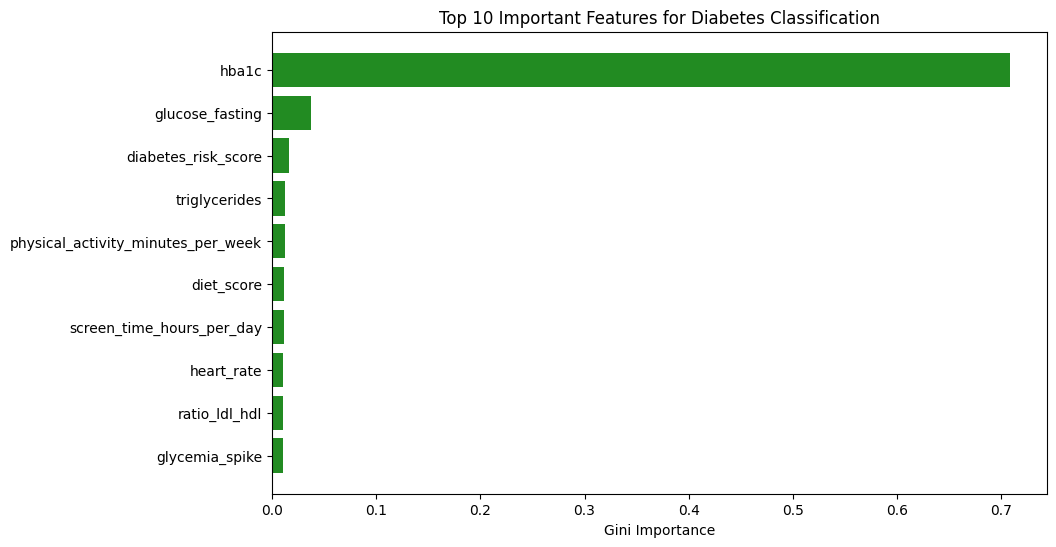

In [2]:
df = pd.read_csv("C:/Users/Tiago Silva/Uni/OneDrive - Universidade Portucalense/Ambiente de Trabalho/Uni/3ano2sem/LAD/Grupo5_ProjetoLAD_Parte2/TrabalhoLAD/data/diabetes_dataset_new_variables.csv")

categorical_cols = [
    'gender', 'ethnicity', 'smoking_status', 'education_level',
    'employment_status', 'age_groups', 'weight_status', 'income_level'
]

# Transform categorical variables using One-Hot Encoding
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define X and y (Scale remains original as DTC is scale invariant)
X = df_final.drop(["diagnosed_diabetes", "diabetes_stage"], axis=1)
y = df_final['diagnosed_diabetes']

# Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

def log_dtc_metrics(y_true, y_pred, duration):
    """Helper function to log performance metrics to MLflow"""
    mlflow.log_metric("recall", recall_score(y_true, y_pred))
    mlflow.log_metric("accuracy", accuracy_score(y_true, y_pred))
    mlflow.log_metric("f1", f1_score(y_true, y_pred))
    mlflow.log_metric("fit_time", duration)

# ---------------------------------------------------------
# RUN 1: BASELINE 
# ---------------------------------------------------------
with mlflow.start_run(run_name="DT_Baseline"):
    # Using Scikit-Learn defaults for baseline comparison
    clf_base = DecisionTreeClassifier(random_state=42)
    
    start_time = time.time()
    clf_base.fit(X_train, y_train)
    duration = time.time() - start_time
    
    y_pred = clf_base.predict(X_test)
    
    mlflow.log_params(clf_base.get_params())
    mlflow.log_param("optimization", "none")
    log_dtc_metrics(y_test, y_pred, duration)

# ---------------------------------------------------------
# RUN 2: GRIDSEARCHCV 
# ---------------------------------------------------------
with mlflow.start_run(run_name="DT_GridSearch"):
    # Parameter grid focusing on controlling tree depth and leaf size
    param_grid = {
        'criterion': ['gini', 'entropy'],
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [2, 10, 20],
        'min_samples_leaf': [1, 5, 10]
    }
    
    grid = GridSearchCV(
        DecisionTreeClassifier(random_state=42),
        param_grid, cv=5, scoring='recall', n_jobs=-1
    )
    
    start_time = time.time()
    grid.fit(X_train, y_train)
    duration = time.time() - start_time
    
    # Predict using the best estimator from grid search
    y_pred_grid = grid.best_estimator_.predict(X_test)
    
    mlflow.log_params(grid.best_params_)
    mlflow.log_param("optimization", "GridSearchCV")
    log_dtc_metrics(y_test, y_pred_grid, duration)
    best_dt_model = grid.best_estimator_

# ---------------------------------------------------------
# RUN 3: OPTUNA 
# ---------------------------------------------------------
def objective(trial):
    params = {
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "max_depth": trial.suggest_int("max_depth", 2, 32),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "random_state": 42
    }
    
    model = DecisionTreeClassifier(**params)
    # Cross-validation using recall as the target metric
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='recall', n_jobs=-1).mean()
    return score

with mlflow.start_run(run_name="DT_Optuna"):
    study = optuna.create_study(direction="maximize")
    start_time = time.time()
    study.optimize(objective, n_trials=30)
    duration = time.time() - start_time
    
    # Train the final model with the best parameters found by Optuna
    best_dt_optuna = DecisionTreeClassifier(**study.best_params, random_state=42)
    best_dt_optuna.fit(X_train, y_train)
    
    mlflow.log_params(study.best_params)
    mlflow.log_param("optimization", "optuna")
    log_dtc_metrics(y_test, best_dt_optuna.predict(X_test), duration)

# ---------------------------------------------------------
# VISUALIZATION: Feature Importance 
# ---------------------------------------------------------
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_dt_model.feature_importances_
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color='forestgreen')
plt.xlabel("Gini Importance")
plt.title("Top 10 Important Features for Diabetes Classification")
plt.gca().invert_yaxis()
plt.show()

## Decision Tree Runs Comparison

| Run | Optimization | Criterion | Max Depth | Min Samples Split | Min Samples Leaf | CCP Alpha | Class Weight | Accuracy | F1 | Recall | Fit Time (s) |
|---|---|---|---:|---:|---:|---:|---|---:|---:|---:|---:|
| DT_Baseline | none | gini | None | 2 | 1 | 0.0 | None | 0.86355 | 0.88700 | 0.89258 | 1.65072 |
| DT_GridSearch | GridSearchCV | gini | None | 2 | 1 | - | - | 0.86355 | 0.88700 | 0.89258 | 52.19126 |
| DT_Optuna | optuna | entropy | 29 | 7 | 3 | - | - | 0.87795 | 0.89726 | 0.88825 | 46.66339 |

### Notes on parameters

- `-` means the parameter was not logged in MLflow for that run.


## Best Run for Streamlit Deployment

For a clinical classification app in Streamlit, we should prioritize **balanced performance** across metrics, not only maximizing one metric.

- **Selected run**: `DT_Optuna`
- **Why**:
  - It has the **highest Accuracy** (0.87795), meaning better overall correctness.
  - It also has the **highest F1-score** (0.89726), which is important to balance false positives and false negatives.
  - Its **Recall** (0.88825) is only slightly below Baseline/GridSearch (0.89258), so sensitivity remains high.

### Trade-off interpretation

- Baseline and GridSearch recover marginally more positive cases (higher recall), but they lose relevant global quality (lower accuracy and F1).
- `DT_Optuna` gives the best overall compromise for production usage, where we want reliable general predictions and not only maximum sensitivity.



## Interpretation of the Top 10 Feature Importance Plot

The chart **Top 10 Important Features for Diabetes Classification** ranks the variables by their contribution to tree splits.

- The x-axis shows **Gini Importance** (relative contribution of each feature).
- The y-axis lists the 10 most influential features.
- Larger bars indicate features that produced larger impurity reductions across the tree.

### How to read it for decision support

- Features at the top are the strongest drivers of model decisions.
- If one or two features dominate too much, the model may be overly dependent on them.
- A more distributed importance profile usually indicates a more robust model.

